In [39]:
%matplotlib qt

Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
['E193', 'E202', 'E17', 'E185', 'E53', 'E63', 'E184', 'E69', 'E62', 'E54', 'E57', 'E132', 'E6', 'E23', 'E43', 'E44']
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
['E193', 'E202', 'E17', 'E185', 'E53', 'E63', 'E184', 'E69', 'E62', 'E54', 'E57', 'E132']


In [1]:
# | tags: [parameters]
subject_id = "170"

In [7]:
from pathlib import Path
import os
import mne
import matplotlib.pyplot as plt
import numpy as np
import mne
from spectral.utils import ProjectPaths, print_timestamp, load_config

print_timestamp("Setting up project paths")
mne.set_config("MNE_BROWSER_THEME", "light")

# Initialize paths for your subject
paths = ProjectPaths(subject_id)
paths.show()


Setting up project paths: 2025-11-27 08:27:03
────────────────────────────────────────────────────────────
Paths for sub-170
Project Root: /Users/daniel/PhD/Projects/psd-paths
────────────────────────────────────────────────────────────
  analysis     : /Users/daniel/PhD/Projects/psd-paths/data/derrivatives/sub-170/analysis
  data         : /Users/daniel/PhD/Projects/psd-paths/data/bids/sub-170
  epochs       : /Users/daniel/PhD/Projects/psd-paths/data/derrivatives/sub-170/epochs
  figures      : /Users/daniel/PhD/Projects/psd-paths/outputs/figures/sub-170
  ica          : /Users/daniel/PhD/Projects/psd-paths/data/derrivatives/sub-170/analysis/ica
  logs         : /Users/daniel/PhD/Projects/psd-paths/data/logs
  outputs      : /Users/daniel/PhD/Projects/psd-paths/outputs
  preprocessed : /Users/daniel/PhD/Projects/psd-paths/data/derrivatives/sub-170/preprocessed
  processing   : /Users/daniel/PhD/Projects/psd-paths/data/derrivatives/sub-170
  reports      : /Users/daniel/PhD/Projects/p

In [8]:
raw_annotated = mne.io.read_raw_fif(f"{paths.preprocessed}/sub-{subject_id}_raw_annotated_filtered_raw.fif", preload=True)

Opening raw data file /Users/daniel/PhD/Projects/psd-paths/data/derrivatives/sub-170/preprocessed/sub-170_raw_annotated_filtered_raw.fif...
    Range : 0 ... 78719 =      0.000 ...   314.876 secs
Ready.
Reading 0 ... 78719  =      0.000 ...   314.876 secs...


In [50]:
from spectral.epochs import create_epochs, get_reject_log

# raw_annotated = raw_pyprep.copy()
epochs = create_epochs(raw_annotated, overlap=1.5)
consensus = np.linspace(0, 1.0, 11)
reject_log = get_reject_log(epochs, resample=125, n_interpolate=[1, 4, 8], consensus=consensus)
reject_plot = reject_log.plot("vertical")


# Drop channels with more than 40% bad epochs
BADS_THRESHOLD = 0.40

bads = np.logical_or(reject_log.labels == 1, reject_log.labels == 2)

bad_channel = bads.mean(axis=0)
# print(bad_channel)
epochs.info
channel_names = epochs.info["ch_names"]
bad_channels_by_epochs = [
    name for name, value in zip(channel_names, bad_channel) if value > BADS_THRESHOLD
]
print(
    f"Additional {len(bad_channels_by_epochs)} bad channels found:{
        bad_channels_by_epochs
    }"
)

try:
    bad_channel_plot_additional = epochs.plot(
        picks=bad_channels_by_epochs,
        scalings=dict(eeg=1e-4),
        show_scrollbars=False,
    )
except Exception as e:
    print(f"An error occurred: {e}")

Not setting metadata
89 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 89 events and 1251 original time points ...
1 bad epochs dropped
fitting finished
Additional 4 bad channels found:['E6', 'E23', 'E43', 'E44']


In [51]:
epochs.info["bads"].extend(bad_channels_by_epochs)
epochs.info["bads"].append("E9")


In [52]:
from spectral.ica import compute_ica
epochs_ica = epochs.copy().filter(l_freq=1.0, h_freq=None)
ica = compute_ica(epochs_ica , n_components=0.99, method="picard")


print(ica.n_components_)
if ica.n_components_ > 50:
    ica = compute_ica(epochs_ica, n_components=50, method="picard")
ica.save(f"{paths.ica}/sub-{subject_id}_my_ica_model-ica.fif", overwrite=True)
ica_plot_components = ica.plot_components()

Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 825 samples (3.300 s)

Fitting ICA to data using 187 channels (please be patient, this may take a while)
Selecting by explained variance: 10 components
Fitting ICA took 1.5s.
10
Overwriting existing file.
Writing ICA solution to /Users/daniel/PhD/Projects/psd-paths/data/derrivatives/sub-170/analysis/ica/sub-170_my_ica_model-ica.fif...
Overwriting existing file.


Including 1 SSP projectors from raw file
Running ECG SSP computation
Using channel ECG to identify heart beats.
Setting up band-pass filter from 5 - 35 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 5.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 4.75 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 35.25 Hz)
- Filter length: 2500 samples (10.000 s)

Number of ECG events detected : 455 (average pulse 87.11468504690791 / min.)
Computing projector
Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 35 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal b

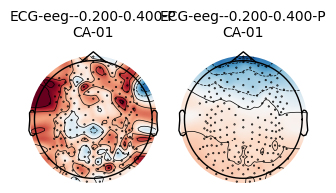

In [63]:
import mne

# Correct way to call the function
ecg_projs, ecg_events = mne.preprocessing.compute_proj_ecg(
    raw_annotated, 
    n_grad=0, 
    n_mag=0, 
    n_eeg=1,       # Number of vectors (1 is usually enough for ECG)
    reject=None    # Set rejection if needed, or None to use all detected beats
)

# 3. Add the projections to the raw data
raw_annotated.add_proj(ecg_projs)

# 4. (Optional but Recommended) View the artifact map before applying
mne.viz.plot_projs_topomap(ecg_projs, raw_annotated.info)

In [56]:
# ica.apply() changes the Raw object in-place, so let's make a copy first:
epochs_ica_copy = epochs_ica.copy()
ica.apply(epochs_ica_copy, exclude=[0])

Applying ICA to Epochs instance
    Transforming to ICA space (10 components)
    Zeroing out 1 ICA component
    Projecting back using 187 PCA components


<Epochs | 88 events (all good), 0 – 5 s (baseline off), ~172.4 MiB, data loaded,
 '1': 88>

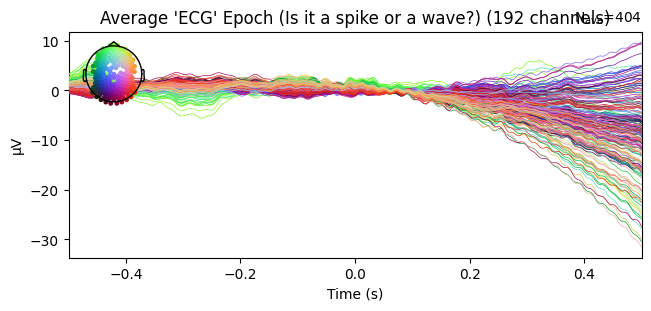

In [64]:
# 1. Visualize the average of the "ECG" epochs
ecg_evoked = ecg_epochs.average()
ecg_evoked.plot(titles="Average 'ECG' Epoch (Is it a spike or a wave?)")

In [58]:
ica_double_run = compute_ica(epochs_ica_copy  , n_components=0.95, method="picard")


print(ica_double_run.n_components_)
#if ica.n_components_ > 50:
#    ica = compute_ica(epochs_ica_copy , n_components=50, method="picard")
#ica.save(f"{paths.ica}/sub-{subject_id}_my_ica_model-ica.fif", overwrite=True)
#ica_plot_components = ica.plot_components()

Fitting ICA to data using 187 channels (please be patient, this may take a while)
Selecting by explained variance: 10 components
Fitting ICA took 1.3s.
10


In [60]:
 ica_plot = ica_double_run.plot_sources(
        epochs_ica_copy ,
        show_scrollbars=True,
        start=0,
        stop=5,
    )

Not setting metadata
88 matching events found
No baseline correction applied
0 projection items activated


Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 1 ICA component
    Projecting back using 187 PCA components


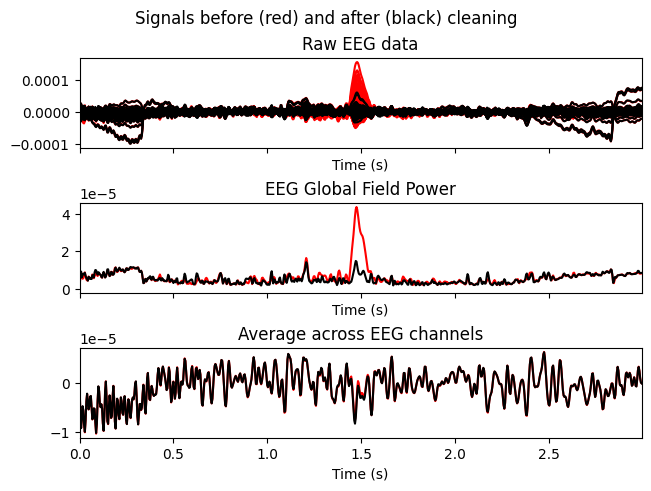

In [54]:
ica.plot_overlay(raw_annotated, exclude=[0], picks="eeg")


In [45]:
ica.plot_properties(epochs_ica, picks=[0])


    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
88 matching events found
No baseline correction applied
0 projection items activated


[<Figure size 700x600 with 6 Axes>]

In [28]:
from mne_icalabel.gui import label_ica_components
from mne_icalabel import label_components


In [34]:
ic_labels = label_components(epochs_ica, ica, method="iclabel")

# ICA0 was correctly identified as an eye blink, whereas ICA12 was
# classified as a muscle artifact.
print(ic_labels["labels"])
#ica.plot_properties(epochs_ica, verbose=False)

/var/folders/xq/sl7xjp_95qx7wfngy6s6vvg00000gn/T/ipykernel_59791/3443488750.py:1: RuntimeWarning: The provided Epochs instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  ic_labels = label_components(epochs_ica, ica, method="iclabel")
/var/folders/xq/sl7xjp_95qx7wfngy6s6vvg00000gn/T/ipykernel_59791/3443488750.py:1: RuntimeWarning: The provided Epochs instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(epochs_ica, ica, method="iclabel")


['eye blink', 'brain', 'other', 'heart beat', 'brain', 'other', 'eye blink', 'brain', 'brain', 'eye blink']


In [46]:
labels = ic_labels["labels"]
exclude_idx = [
    idx for idx, label in enumerate(labels) if label not in ["brain", "other"]
]
print(f"Excluding these ICA components: {exclude_idx}")

Excluding these ICA components: [0, 3, 6, 9]


In [47]:
ica.plot_properties(epochs_ica, picks=exclude_idx, verbose=False)

[<Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>]

Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 4 ICA components
    Projecting back using 188 PCA components


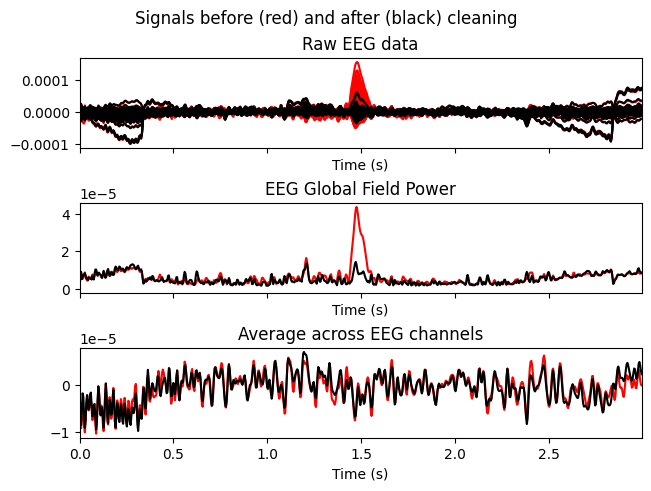

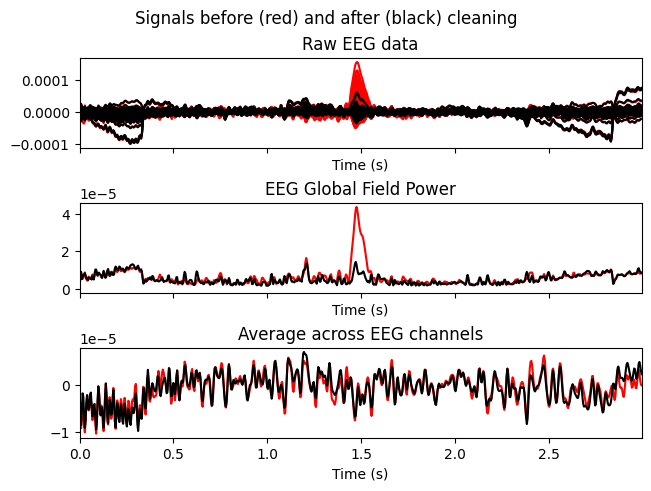

In [37]:
ica.plot_overlay(raw_annotated, exclude=exclude_idx, picks="eeg")


Applying ICA to Epochs instance
    Transforming to ICA space (10 components)
    Zeroing out 4 ICA components
    Projecting back using 188 PCA components


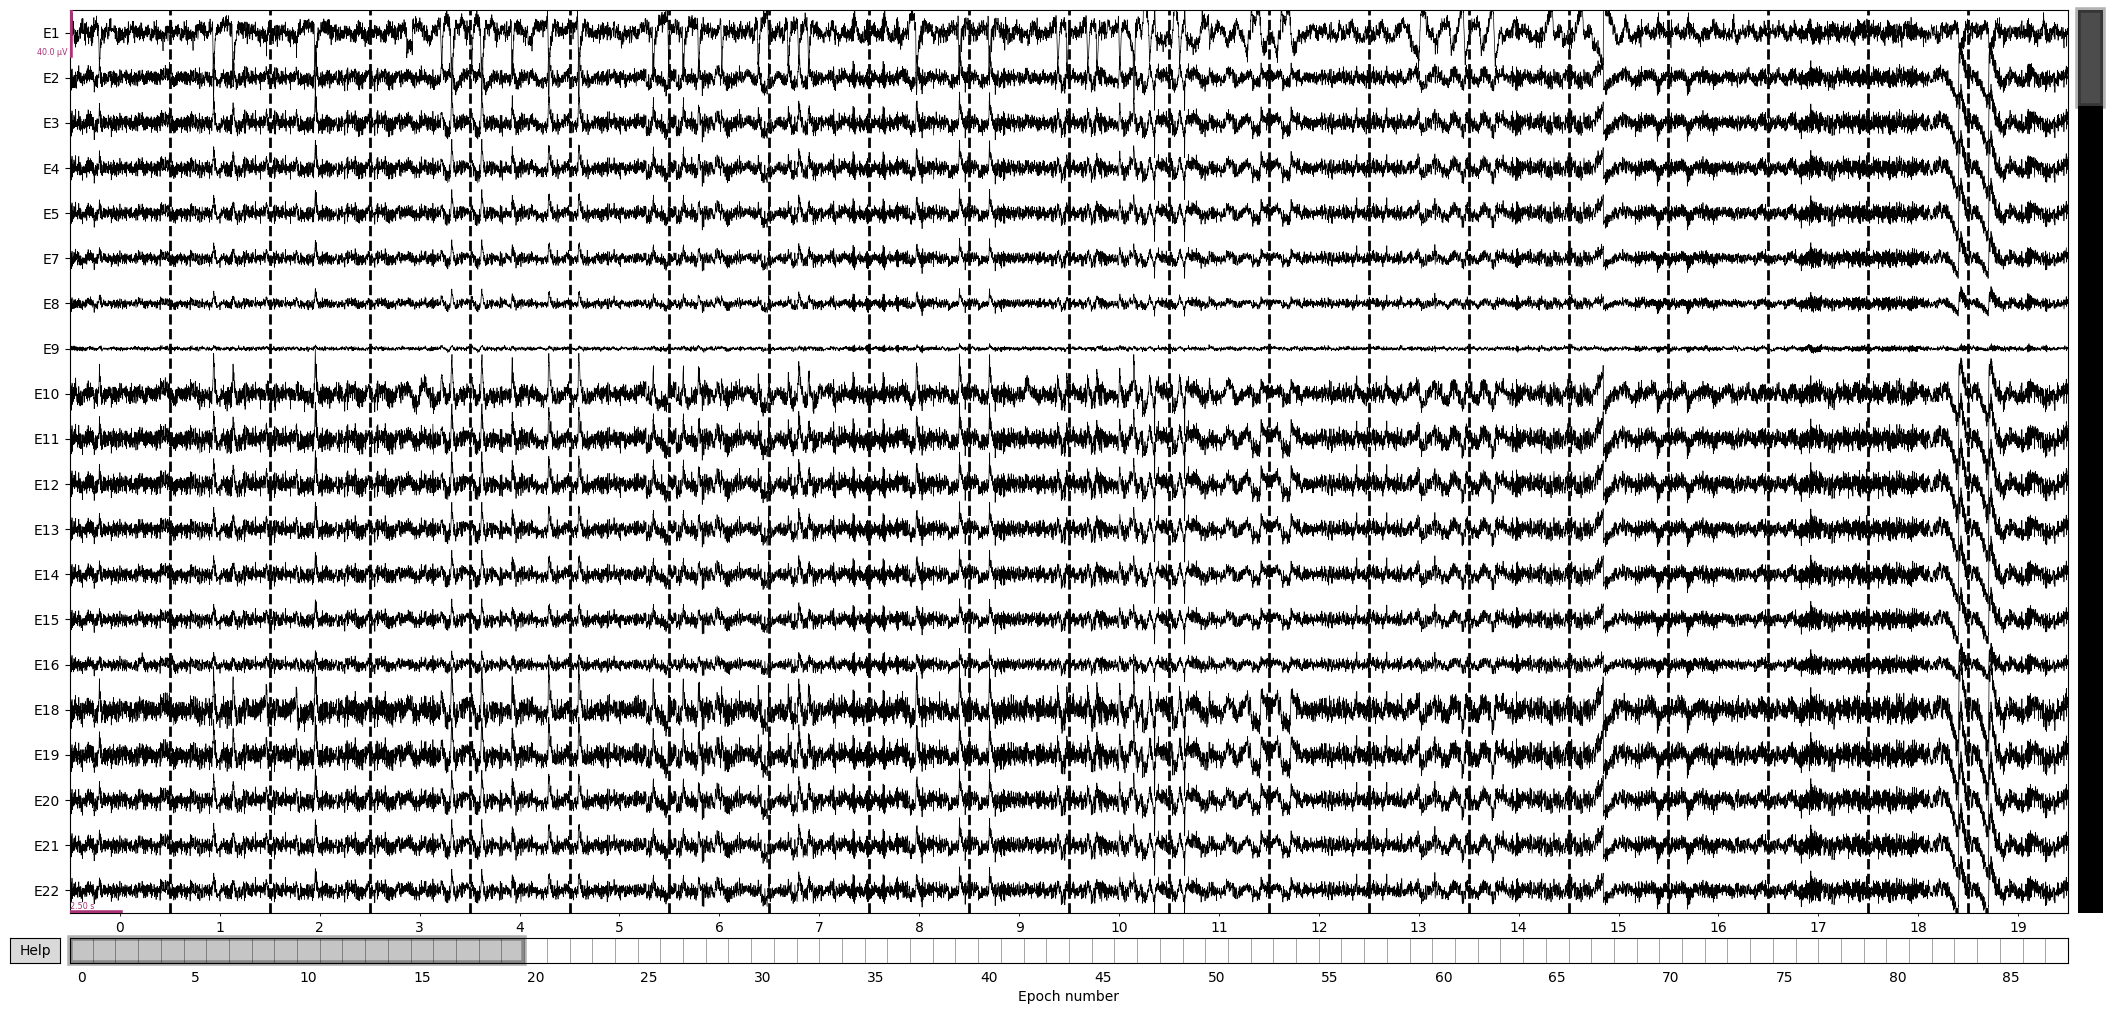

In [40]:
# ica.apply() changes the Raw object in-place, so let's make a copy first:
epochs_ica_copy = epochs_ica.copy()
ica.apply(epochs_ica_copy, exclude=exclude_idx)
epochs_ica_copy.plot()
#raw.plot(order=artifact_picks, n_channels=len(artifact_picks), show_scrollbars=False)
#reconst_raw.plot(
#    order=artifact_picks, n_channels=len(artifact_picks), show_scrollbars=False
#)